# Ejercicio Integrador — Rating, Sentimiento y Perfil de Viajero
 
Una cadena de hoteles quiere entender qué hace que una estadía sea buena o mala, más allá del promedio de estrellas. Tienen 340 reseñas de sus hoteles, con el texto completo de cada reseña y datos de quién la escribió. Se pide un análisis que combine el rating, el texto y el perfil del viajero para producir conclusiones accionables.
 
## Dataset
 
`reviews_hoteles.csv` — 340 filas, 8 columnas:
 
| Columna | Descripción |
|---|---|
| `fecha` | Fecha de la reseña |
| `hotel` | Nombre del hotel |
| `ciudad` | Ciudad donde está el hotel |
| `categoria_hotel` | Categoría oficial del hotel, en estrellas (1 a 5, fija por hotel) |
| `rating_usuario` | Puntuación que el huésped le dio a su estadía (1 a 5) |
| `review` | Texto de la reseña |
| `motivo_viaje` | Negocios, Familia, Pareja, Amigos o Solo |
| `procedencia` | País de origen del huésped |

## Consigna
 
1. **EDA sobre rating.** Explorar la distribución de `rating_usuario` y compararla contra `categoria_hotel`. ¿Los hoteles de más estrellas tienen, en promedio, mejor rating de usuario?

In [14]:
import pandas as pd
df = pd.read_csv("./reviews_hoteles.csv")
print(df["rating_usuario"].describe())

resumen_categoria = (
    df.groupby("categoria_hotel")["rating_usuario"]
        .agg(["count","mean","median","std"])
        .round(2)
    )

print(resumen_categoria)

correlacion = df["categoria_hotel"].corr(df["rating_usuario"])
print(correlacion)



count    340.000000
mean       3.450000
std        1.287734
min        1.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: rating_usuario, dtype: float64
                 count  mean  median   std
categoria_hotel                           
2                   35  3.63     4.0  1.24
3                  138  3.46     4.0  1.31
4                  112  3.45     4.0  1.28
5                   55  3.33     4.0  1.31
-0.05229060124808612


2. **Análisis de sentimiento.** Usar una herramienta de NLP ya entrenada para español (no entrenar ningún modelo propio) para clasificar cada `review` como positiva, negativa o neutra.

In [22]:
pip install pysentimiento

  Using cached pysentimiento-0.7.3-py3-none-any.whl.metadata (7.7 kB)
  Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl.metadata (28 kB)
  Using cached transformers-5.15.1-py3-none-any.whl.metadata (32 kB)
Using cached pysentimiento-0.7.3-py3-none-any.whl (39 kB)
Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl (14.4 MB)
Using cached transformers-5.15.1-py3-none-any.whl (11.7 MB)

   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from pysentimiento import create_analyzer

analizador = create_analyzer(task="sentiment", lang="es")

def clasificar_sentimiento(texto):
    resultado = analizador.predict(str(texto))
    etiquetas = {
        "POS": "positiva",
        "NEG": "negativa",
        "NEU": "neutra"
    }
    return etiquetas[resultado.output]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3025.54it/s]


3. **Rating vs. sentimiento.** Convertir `rating_usuario` a una categoría comparable con el sentimiento detectado, y encontrar los casos donde no coinciden. Calcular qué porcentaje de las reseñas cae en cada caso.

In [26]:
df["sentimiento"] = df["review"].apply(clasificar_sentimiento)

print("Distribución del sentimiento:")
display(df["sentimiento"].value_counts())

print("Porcentaje por sentimiento:")
display((df["sentimiento"].value_counts(normalize=True) * 100).round(2))


Distribución del sentimiento:


sentimiento
positiva    210
negativa     73
neutra       57
Name: count, dtype: int64

Porcentaje por sentimiento:


sentimiento
positiva    61.76
negativa    21.47
neutra      16.76
Name: proportion, dtype: float64

4. **Segmentación por perfil.** Comparar rating y sentimiento según `motivo_viaje` y `procedencia`. ¿Hay diferencias entre cómo puntúan los viajeros de negocios y los de ocio?

In [28]:
segmento = df.groupby("motivo_viaje")["sentimiento"].value_counts(normalize=True).unstack().fillna(0) * 100
print("\nDistribucion de sentimiento segun motivo de viaje:")
display(segmento.round(1))


Distribucion de sentimiento segun motivo de viaje:


sentimiento,negativa,neutra,positiva
motivo_viaje,,,
Amigos,25.4,20.9,53.7
Familia,21.2,13.8,65.0
Negocios,20.0,15.4,64.6
Pareja,20.8,16.7,62.5
Solo,20.0,17.5,62.5


5. **Brecha categoría-experiencia.** Por hotel, calcular la diferencia entre `categoria_hotel` y el `rating_usuario` promedio. Identificar los hoteles con mayor brecha negativa.

In [ ]:
# Tu codigo acá

In [29]:
brecha_hotel = (
    df.groupby("hotel")
      .agg(
          categoria_hotel=("categoria_hotel", "first"),
          rating_promedio=("rating_usuario", "mean"),
          cantidad_resenas=("rating_usuario", "count")
      )
)

brecha_hotel["brecha"] = (
    brecha_hotel["rating_promedio"] - brecha_hotel["categoria_hotel"]
)

brecha_hotel = brecha_hotel.sort_values("brecha").round(2)

print("Hoteles con mayor brecha negativa:")
display(brecha_hotel.head(10))

Hoteles con mayor brecha negativa:


,categoria_hotel,rating_promedio,cantidad_resenas,brecha
hotel,,,,
Resort Laguna Azul,5,3.23,22,-1.77
Gran Hotel Andes,5,3.39,33,-1.61
Cabañas del Bosque,4,3.30,33,-0.70
Hotel Río Claro,4,3.49,39,-0.51
Boutique Palermo Suites,4,3.52,40,-0.48
Hotel Costa Azul,3,3.19,36,0.19
Posada del Sol,3,3.50,38,0.50
Hotel Central Plaza,3,3.54,28,0.54
Hotel Faro Viejo,3,3.61,36,0.61


6. **Visualización.** Al menos dos gráficos: uno que cruce rating y sentimiento, y otro que compare sentimiento entre segmentos de viajero.

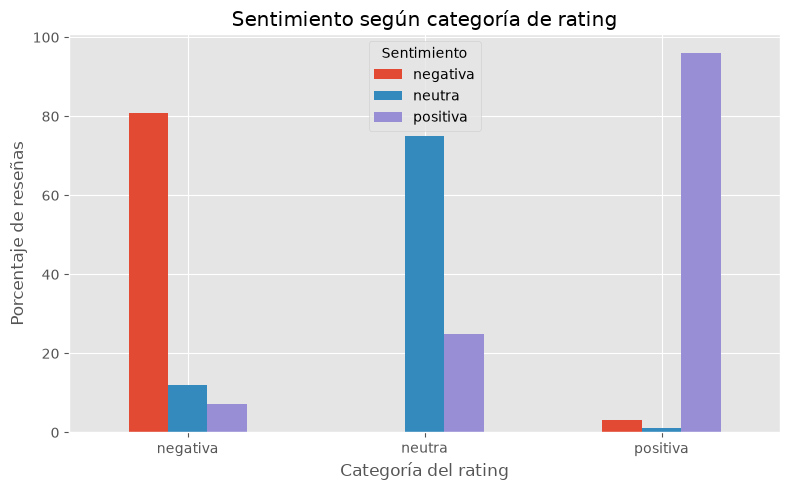

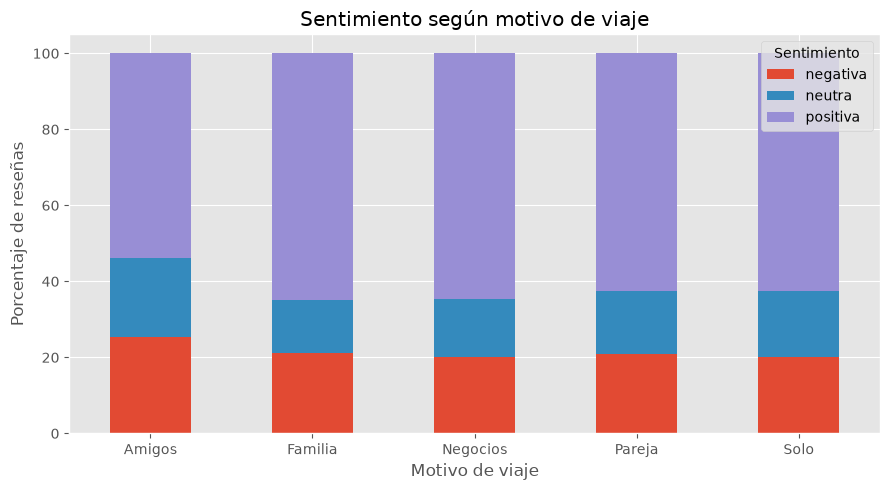

In [30]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
# Clasificar el rating en categorías comparables con el sentimiento
df["categoria_rating"] = pd.cut(
    df["rating_usuario"],
    bins=[0, 2, 3, 5],
    labels=["negativa", "neutra", "positiva"]
)

# Gráfico 1: rating versus sentimiento
cruce_rating = pd.crosstab(
    df["categoria_rating"],
    df["sentimiento"],
    normalize="index"
) * 100

cruce_rating = cruce_rating.reindex(
    index=["negativa", "neutra", "positiva"],
    columns=["negativa", "neutra", "positiva"],
    fill_value=0
)

cruce_rating.plot(kind="bar", figsize=(8, 5))
plt.title("Sentimiento según categoría de rating")
plt.xlabel("Categoría del rating")
plt.ylabel("Porcentaje de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()

# Gráfico 2: sentimiento según segmento de viajero
segmento[["negativa", "neutra", "positiva"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Sentimiento según motivo de viaje")
plt.xlabel("Motivo de viaje")
plt.ylabel("Porcentaje de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()

7. **Storytelling.** Con los resultados anteriores, escribir una conclusión de negocio de 3 a 5 oraciones dirigida a la cadena de hoteles. Debe basarse en los números encontrados, no en impresiones generales.

In [31]:
# Storytelling: conclusión de negocio basada en los números del análisis
pct_positiva = df["sentimiento"].value_counts(normalize=True).get("positiva", 0) * 100
pct_negativa = df["sentimiento"].value_counts(normalize=True).get("negativa", 0) * 100
pct_neutra = df["sentimiento"].value_counts(normalize=True).get("neutra", 0) * 100

conclusion = (
    f"El análisis no muestra que los hoteles de más estrellas reciban mejor calificaciones de experiencia: el promedio de calificaciones de ususarios desciende de "
    f"{resumen_categoria.loc[2, 'mean']:.2f} en categoría 2 a {resumen_categoria.loc[5, 'mean']:.2f} en categoría 5, "
    f"y la correlación entre categoría y rating es muy baja ({correlacion:.3f}). "
    f"En términos de sentimiento, la mayoría de las reseñas son positivas con un {pct_positiva:.1f}%, pero aún hay una proporción importante "
    f"de negativas ({pct_negativa:.1f}%) y neutras ({pct_neutra:.1f}%), con perfiles muy similares entre viajeros de negocios y ocio "
    f"(64.6% y 65.0% de sentimiento positivo, respectivamente). "
    f"El principal riesgo opera en los hoteles con mayor brecha negativa: Resort Laguna Azul y Gran Hotel Andes quedaron "
    f"{abs(brecha_hotel.iloc[0]['brecha']):.2f} y {abs(brecha_hotel.iloc[1]['brecha']):.2f} puntos por debajo de su categoría, "
    f"lo que sugiere que la cadena debe corregir la experiencia en sus hoteles premium y no asumir que la categoría física garantiza una buena estadía."
)

print(conclusion)

El análisis no muestra que los hoteles de más estrellas reciban mejor calificaciones de experiencia: el promedio de calificaciones de ususarios desciende de 3.63 en categoría 2 a 3.33 en categoría 5, y la correlación entre categoría y rating es muy baja (-0.052). En términos de sentimiento, la mayoría de las reseñas son positivas con un 61.8%, pero aún hay una proporción importante de negativas (21.5%) y neutras (16.8%), con perfiles muy similares entre viajeros de negocios y ocio (64.6% y 65.0% de sentimiento positivo, respectivamente). El principal riesgo opera en los hoteles con mayor brecha negativa: Resort Laguna Azul y Gran Hotel Andes quedaron 1.77 y 1.61 puntos por debajo de su categoría, lo que sugiere que la cadena debe corregir la experiencia en sus hoteles premium y no asumir que la categoría física garantiza una buena estadía.


## Pistas
 
- Para el análisis de sentimiento, `pysentimiento` es una librería en Python con un modelo ya entrenado para español — no hace falta entrenar nada, se instala y se usa directo.
- `categoria_hotel` y `rating_usuario` son cosas distintas: una es fija por hotel, la otra varía por reseña. La consigna 5 depende de no confundirlas.
- Para "no coincide" en la consigna 3, primero hay que llevar el rating a la misma escala que devuelve el modelo de sentimiento (positivo / negativo / neutro).
- Conviene resolver la consigna 1 antes que la 2 — tener una idea de cómo se distribuye el rating ayuda a interpretar mejor los resultados del sentimiento después.